In [1]:
from pathlib import Path
from os import environ


IN_COLAB = False
if "DRIVE_HOME" in environ:
  ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
else:
  ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
outputdir = Path(f"{basedir}/data")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using outputdir={outputdir}")

Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data


In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [3]:
n_trials=100 # number of dna sites checked
regimes = [50, 250, 5000] # number of samples per trial for each regime

dgps_file = Path(f"{basedir}/data/dgp.csv")
if dgps_file.exists(): # check if this data has already been generated
    print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
    if dgps_file.parent: # create parents dir if not already
        dgps_file.parent.mkdir(parents=True, exist_ok=True)

    dsids = ["regular", "e-singular", "singular1", "singular2"]
    dgps_raw = {
        "dsid"  : dsids,
        "p0" : np.array([0.15, 0.25, 0.15, 0.35]), # probability of per site mutation if MSI1 tumor
        "p1" : np.array([0.35, 0.35, 0.35, 0.35]), # probability of per site mutation if MSI2 tumor
        "w0" : np.array([0.75, 0.75, 1, 0.75]), # probability of selecting a person with MSI1 tumor
    }
    dgps_raw["w1"] = 1-dgps_raw["w0"]
    pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
    print(f"File {dgps_file} created!.")

dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/dgp.csv exists, skipping experiments meta!.


,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [4]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [5]:
from sklearn_extensions.mixture import BinomialMixture
data = {}
num_replications=1000
for dsid in dgps["dsid"].unique():
    data[dsid]={}
    for regime in regimes:
        obs_file = Path(f"{basedir}/data/{dsid}-{regime}.csv") # where we are going to store observations
        if obs_file.exists(): # check if this data has already been generated
            print(f"File {obs_file} exists, skipping random samples creation!.")
        else:
            if obs_file.parent: # create parents dir if not already
                obs_file.parent.mkdir(parents=True, exist_ok=True)

            results = {}
            for i in range(num_replications):
                dgp = dgps.query(f"dsid=='{dsid}'")
                weights = dgp[["w0", "w1"]].iloc[0].tolist()
                probs = dgp[["p0", "p1"]].iloc[0].tolist()
                dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
                samples = dd.sample(n_samples=regime)
                results[f"r{i}"]=samples[0]


            data_df = pd.DataFrame(results)
            data_df.to_csv(obs_file, index=False)
            print(f"File {obs_file} created!.")

        data[dsid][regime]=pd.read_csv(obs_file, index_col=0).reset_index()
        dgp = dgps.query(f"dsid == '{dsid}'")

        data[dsid]["truth"] = f"$(w_0={dgp['w0'].item()}, p_0={dgp['p0'].item()}, p_1={dgp['p1'].item()})$"

    print(f"Loaded {len(data[dsid])-1} {dsid} datasets")

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/regular-50.csv exists, skipping random samples creation!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/regular-250.csv exists, skipping random samples creation!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/regular-5000.csv exists, skipping random samples creation!.
Loaded 3 regular datasets
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/e-singular-50.csv exists, skipping random samples creation!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data/e-singular-250.csv exists, skipping random samples creation!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixtu

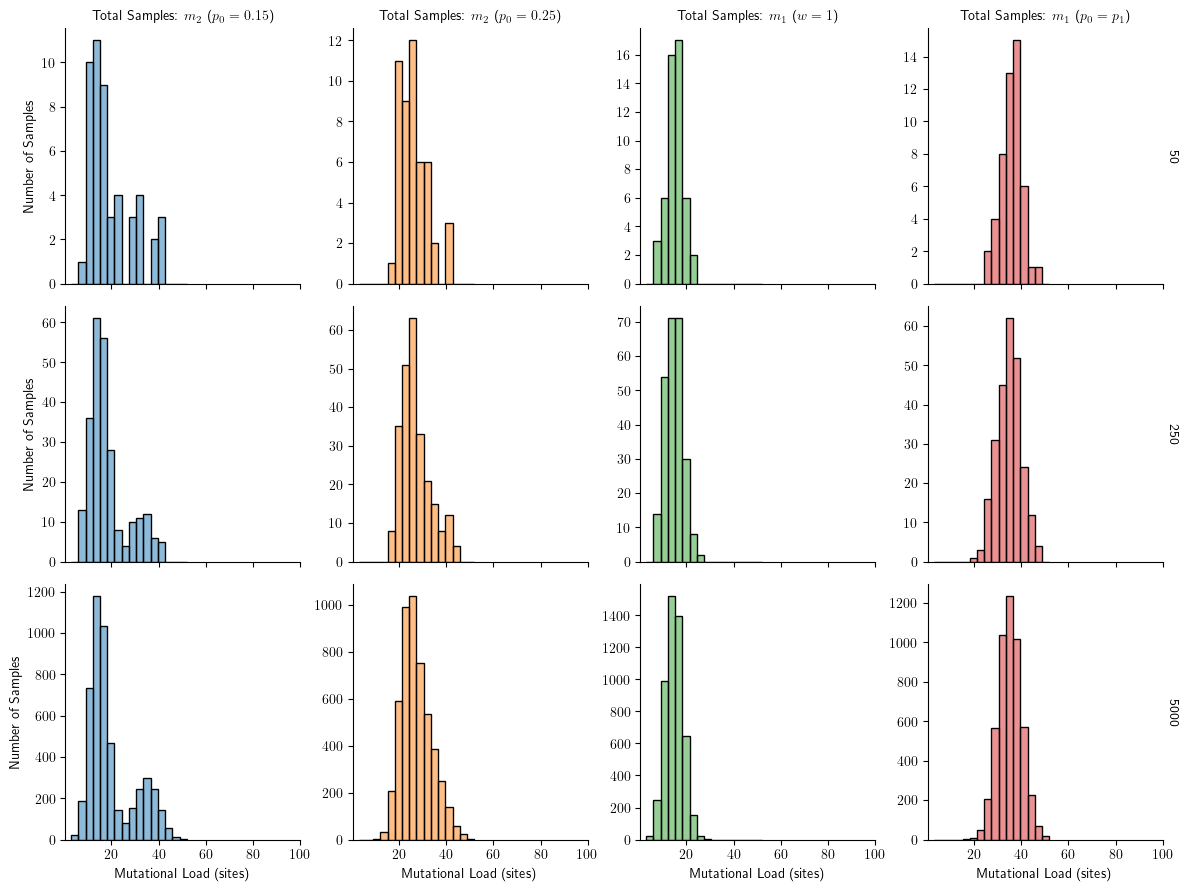

In [9]:
datasets = dgps["dsid"].unique()

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "size": [], "dsid": []} # raw data to initialize the plotting dataframe

# Set custom row labels with LaTeX
dsid_labels = {
  "regular": r"$m_2$ ($p_0=0.15$)",
  "e-singular": r"$m_2$ ($p_0=0.25$)",
  "singular1": r"$m_1$ ($w=1$)",
  "singular2": r"$m_1$ ($p_0=p_1$)",
}

for dsid in datasets:
    dgp = dgps.query(f"dsid == '{dsid}'")
    for ss in regimes:
        x = data[dsid][5000].iloc[:ss,1]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["size"]=np.append(plotdata["size"], (np.ones(ss)*ss).astype(int))
        plotdata["dsid"]=np.append(plotdata["dsid"], [dsid for i in np.ones(ss)])

plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "size": int, "dsid": str})
plotdf["dgp_label"] = plotdf["dsid"].map(dsid_labels)
g=sns.displot(plotdf,
              x="x", col="dgp_label", row="size", bins=n_trials, hue="dsid",
              binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": False}, legend=False, palette=default_palette)

g.set_axis_labels("Mutational Load (sites)", "Number of Samples")
g.set_titles(col_template="Total Samples: {col_name}", row_template=f"{{row_name}}")

for ax in g.axes.flat:
    ax.set_xticks(list(range(20, 110, 20)))

datasets_hist_file = Path(f'{basedir}/data/dataset_hist.png')
if datasets_hist_file.parent: # create parents dir if not already
    datasets_hist_file.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(datasets_hist_file, dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Load data
dsids = dgps["dsid"]
data = {}
for dsid in dsids:
    data[dsid]={}
    for regime in regimes:
        data[dsid][regime]=pd.read_csv(f"{basedir}/data/{dsid}-{regime}.csv", index_col=0).reset_index()

print(f"loaded {list(data.keys())} samples")

loaded ['regular', 'e-singular', 'singular1', 'singular2'] samples


In [16]:
from sklearn_extensions.binomial import BinomialMixture, mixbinom_divergence, Divergence
from sklearn_extensions.confidence_regions.gaussian import CovarianceProvider, GaussianCRProvider
from sklearn_extensions.confidence_regions import confidence_estimates
from sklearn_extensions.confidence_regions.gaussian import GaussianCRProvider, CovarianceProvider
from sklearn_extensions.confidence_regions.bootstrap import BootstrapCRProviderFactory

def point_estimator_factory(
    # max_iter=10**3, tol=1e-3, n_init=50
):
    def estimator(data):
        model=BinomialMixture(n_components=2, n_trials=n_trials
                              # , max_iter=10**3, tol=10**3, n_init=50
                             )
        model.fit(data)
        return model.point_estimate()

    return estimator


mle_file = Path(f"{basedir}/data/mle.csv")
if mle_file.exists(): # check if this data has already been generated
    print(f"File {mle_file} exists, skipping mle computation!.")
else:
    distance_fun = mixbinom_divergence(n_trials=2, kind=Divergence.Euclidean, allow_marginals=False)
    
    stats_data = []
    errors_data = []
    ci_data = []
    
    for dsid, dd in tqdm(data.items(), "datasets "):
        model=BinomialMixture(n_components=2, n_trials=n_trials, enforce_ordering=True)
        truth = find_truth_by_dsid(dsid=dsid)
        for ss in tqdm(regimes, "regimes "):
            sample_data = dd[5000].iloc[:ss,1].to_numpy()
            X=sample_data.reshape(len(sample_data),1)
            model.fit(np.array(X))
            mle, mle_detail = model.point_estimate()
            fmat = model.fisher_matrix(X)
            cov_provider = CovarianceProvider(fisher_mat = fmat)
            cov = cov_provider.cov_mat()
            stderrors = cov_provider.standard_errors()

            bootstrap_provider_factory = BootstrapCRProviderFactory(data=X, 
                                                                    point_estimator=point_estimator_factory(), 
                                                                    n_params=len(truth), 
                                                                    n_iterations=10**3)

            gaus_ci_provider = GaussianCRProvider(mle=mle, cov_provider=cov_provider)
            gaus_ci_interval = gaus_ci_provider.intervals(confidence_level=0.95)
            
            boot_ci_provider = bootstrap_provider_factory.new_provider()
            boot_ci_interval = boot_ci_provider.intervals(confidence_level=0.95)
    
            for pindex, pname in enumerate(["p0", "p1", "w0"]):
                stats_data.append({
                    "dsid": dsid,
                    "n": ss,
                    "pname": pname,
                    "mle": mle[pindex],
                    "truth": truth[pindex],
                    "estimate_fisher_info": fmat[pindex, pindex],
                    "estimate_var": cov[pindex, pindex],
                    "estimate_std_error": stderrors[pindex],
                    "abs_error": np.abs(mle[pindex]-truth[pindex]),
                    "squared_error": (mle[pindex]-truth[pindex])**2
                })
    
                new_row = {
                    "dsid": dsid,
                    "n": ss,
                    "pname": pname,
                }
                for criteria in ["est_fisher_info", "est_var", "actual_abs_error"]:
                    match criteria:
                        case "est_fisher_info":
                            new_row = new_row | {"oname": criteria, "ovalue": fmat[pindex, pindex]}
                        case "est_var":
                            new_row = new_row | {"oname": criteria, "ovalue": cov[pindex, pindex]}
                        case "est_std_error":
                            new_row = new_row | {"oname": criteria, "ovalue": stderrors[pindex]}
                        case "actual_abs_error":
                            if dsid == "singular1":
                                match pname:
                                    case "p1":
                                        new_row = new_row | {"oname": criteria, "ovalue": np.abs(mle[pindex]-truth[0])}
                                    case "w0":
                                        new_row = new_row | {"oname": criteria, 
                                                             "ovalue": min(np.abs(mle[pindex]-truth[2]), 
                                                                              np.abs(mle[pindex]-(1-truth[2])))}
                                    case _:
                                        new_row = new_row | {"oname": criteria, "ovalue": np.abs(mle[pindex]-truth[0])}

                            else:
                                new_row = new_row | {"oname": criteria, "ovalue": np.abs(mle[pindex]-truth[pindex])}
                        case _:
                            raise Exception("not supported!")
                    errors_data.append(new_row)

                
                for method in ["gaus_approx", "bootstrap"]:
                    new_ci_row = {
                        "dsid": dsid,
                        "n": ss,
                        "pname": pname,
                        "mle": mle[pindex]
                    }
                    match method:
                        case "gaus_approx":
                            new_ci_row = new_ci_row | {"method": method,
                                                       "upper": gaus_ci_interval[pindex][0],
                                                       "lower": gaus_ci_interval[pindex][1]}
                        case "bootstrap":
                            new_ci_row = new_ci_row | {"method": method,
                                                       "upper": boot_ci_interval[pindex][0],
                                                       "lower": boot_ci_interval[pindex][1]}
                        case _:
                            raise Exception("not yet implemented!")
                    ci_data.append(new_ci_row)

                            
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_csv(mle_file)
    
    errors_df = pd.DataFrame(errors_data)
    errors_df.to_csv(f"{basedir}/data/mle_errors.csv")

    ci_data_df = pd.DataFrame(ci_data)
    ci_data_df.to_csv(f"{basedir}/data/mle_ci.csv")

stats_df = pd.read_csv(mle_file)
errors_df = pd.read_csv(f"{basedir}/data/mle_errors.csv")
ci_data_df = pd.read_csv(f"{basedir}/data/mle_ci.csv")

datasets :   0%|          | 0/4 [00:00<?, ?it/s]

regimes :   0%|          | 0/3 [00:00<?, ?it/s]

bootstrap :   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
stats_df = pd.DataFrame(stats_data)
stats_df.to_csv(Path(f"{basedir}/mle.csv"))

errors_df = pd.DataFrame(errors_data)
errors_df.to_csv(f"{basedir}/mle_errors.csv")

ci_data_df = pd.DataFrame(ci_data)
ci_data_df.to_csv(f"{basedir}/mle_ci.csv")

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:.5f}')
stats_df.round(5)

In [ ]:
ci_data_df.round(5)
# errors_df.to_csv("./data/ci_forest.csv")

In [ ]:
# Your data (example)
# ci_df has columns: dsid, n, pname, mle, method, upper, lower

# Define orders and colors
dsid_order = ['regular', 'e-singular', 'singular1']
pname_order = ['p0', 'p1', 'w0']
# method_order = ['gaus_approx', 'bootstrap', 'profile_likelihood']
method_order = ['gaus_approx', 'bootstrap']

method_colors = {
    'gaus_approx': '#2E86AB',
    'bootstrap': '#A23B72',
    # 'profile_likelihood': '#F18F01'
}

# Small horizontal offset so methods don't overlap at same n
method_offsets = {
    'gaus_approx': -0.08,
    'bootstrap': 0.0,
    # 'profile_likelihood': 0.08
}

ci_df = ci_data_df

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey='row')

for i, dsid in enumerate(dsid_order):
    for j, pname in enumerate(pname_order):
        ax = axes[i, j]
        
        subset = ci_df[(ci_df['dsid'] == dsid) & (ci_df['pname'] == pname)]
        
        if len(subset) == 0:
            continue
        
        # Get unique sample sizes for x-axis positioning
        sample_sizes = sorted(subset['n'].unique())
        
        # Map n to log-spaced x positions for better visualization
        n_to_x = {n: idx for idx, n in enumerate(sample_sizes)}
        
        # Plot each method
        for method in subset['method'].unique():
            method_data = subset[subset['method'] == method]
            color = method_colors.get(method, 'gray')
            offset = method_offsets.get(method, 0)
            
            for _, row in method_data.iterrows():
                x = n_to_x[row['n']] + offset
                
                # Vertical CI line
                ax.vlines(x, row['lower'], row['upper'], 
                         color=color, linewidth=2.5, alpha=0.8)
                
                # Caps on ends
                cap_width = 0.05
                ax.hlines(row['lower'], x - cap_width, x + cap_width,
                         color=color, linewidth=2)
                ax.hlines(row['upper'], x - cap_width, x + cap_width,
                         color=color, linewidth=2)
                
                # MLE point
                ax.plot(x, row['mle'], 'o', color=color,
                       markersize=8, markeredgecolor='white', 
                       markeredgewidth=1.5, zorder=5)

                ax.set_ylim([-.1, 1.1])
        # True value line (if you have it)
        # true_val = true_values[dsid][pname]
        # ax.axhline(true_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        # X-axis formatting
        ax.set_xticks(range(len(sample_sizes)))
        ax.set_xticklabels(sample_sizes)
        
        # Labels
        if i == 2:
            ax.set_xlabel('Sample size (n)', fontsize=11)
        if j == 0:
            ax.set_ylabel(f'{dsid}\nParameter Value', fontsize=11, fontweight='bold')
        if i == 0:
            ax.set_title(f'${pname}$', fontsize=13, fontweight='bold')
        
        ax.grid(True, axis='y', alpha=0.3, linestyle=':')

# Create legend
handles = [plt.Line2D([0], [0], color=c, linewidth=3, marker='o', 
                      markersize=8, label=m.replace('_', ' ').title())
           for m, c in method_colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, 
           fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('./data/figure_4_ci_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(errors_df)

g = sns.relplot(
    data=errors_df, 
    kind="line", 
    col="pname", 
    row="oname", 
    hue="dsid", 
    x="n", 
    y="ovalue",
    marker='o',
    height=3,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True}  # different y-scales per row
)

g.set(xscale='log', yscale='log')
g.legend.set_bbox_to_anchor((1.02, 0.5))  # move to right side
# Remove individual panel titles
g.set_titles("")
# plt.tight_layout()
# plt.subplots_adjust(right=0.85)  # make room
# plt.show()


# Add single column titles (top row only)
for ax, col_name in zip(g.axes[0], g.col_names):
    ax.set_title(col_name, fontweight='bold')

# Add single row titles (right side or left side)
# Option A: Right side
for ax, row_name in zip(g.axes[:, -1], g.row_names):
    ax.annotate(row_name, xy=(1.05, 0.5), xycoords='axes fraction',
                rotation=-90, va='center', ha='left', fontweight='bold')

# Option B: Left side (as ylabel)
for ax, row_name in zip(g.axes[:, 0], g.row_names):
    ax.set_ylabel(row_name, fontweight='bold', fontsize=11)

g.figure.subplots_adjust(top=0.93, right=0.9)
g.figure.suptitle('Fisher Information vs Variance vs Absolute Error', fontsize=14)

datasets_hist_file = Path(f'{datadir}/data/mle_errors.png')
plt.savefig(datasets_hist_file, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn_ext.confidence_regions import confidence_estimates
from sklearn_ext.confidence_regions.gaussian import GaussianCRProvider, CovarianceProvider
from sklearn_ext.confidence_regions.bootstrap import BootstrapCRProviderFactory

def point_estimator_factory(# max_iter=10**3, tol=1e-3, n_init=50):
    def estimator(data):
        model=BinomialMixture(n_components=2, n_trials=n_trials
                              # , max_iter=10**3, tol=10**3, n_init=50
                             )
        model.fit(data)
        model._enforce_ordering()
        return model.point_estimate()

    return estimator

    


cov_provider = CovarianceProvider(fisher_mat = model.fisher_matrix(data))
bootstrap_provider_factory = BootstrapCRProviderFactory(data=data, 
                                                point_estimator=point_estimator_factory(), 
                                                n_params=len(truth), 
                                                n_iterations=10**3)

cr_providers = [
    GaussianCRProvider(mle=mle, cov_provider=cov_provider),
    bootstrap_provider_factory.new_provider()
]

pp_data, cr_data = confidence_estimates(truth=truth,
                     mle=mle_detail,
                     cov_provider=cov_provider,
                     cr_providers=cr_providers,
                     data=data)

In [ ]:
ci_data = []

regimes = ['regular', 'e-singular', 'singular1']
sample_sizes = [50, 250, 2500]
methods = ['Gaussian', 'Bootstrap', 'Profile Likelihood']

for dsid in dgps["dsid"].unique():
    truth = find_truth_by_dsid(dsid)
    
    for n in sample_sizes:
        euclidean_div = mixbinom_divergence(kind=Divergence.Euclidean, 
                                            n_trials=n_trials, 
                                            allow_marginals=False)
        mle = true_val + np.random.normal(0, 0.1/np.sqrt(n))
        
        for method in methods:
            # Simulated CI bounds (replace with your actual values)
            width = np.random.uniform(0.05, 0.15) / np.sqrt(n)
            
            data.append({
                'regime': regime,
                'n': n,
                'method': method,
                'lower': mle - width,
                'upper': mle + width,
                'estimate': mle,
                'true_value': true_val
            })


# import random
# compute the confidence region using gaussian approximation
estimates={"dsid": [], "n": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "confidence_regions": []}
for dsid in datasets:
    for n in tqdm(n_steps, desc=f"n_steps"):
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        Xs = pd.read_csv(file)
        estimate, model =compute_mle(x_obs=Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["dsid"].append(dsid)
        estimates["n"].append(n)
        estimates["rho1"].append(estimate["rho1"])
        estimates["rho2"].append(estimate["rho2"])
        estimates["p1"].append(estimate["p1"])
        estimates["p2"].append(estimate["p2"])
        confidence_region_data = model.compute_fisher_confidence_region(Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["cov_matrix"].append(confidence_region_data["cov_matrix"])
        estimates["chi2_critical"].append(confidence_region_data["chi2_critical"])
        estimates["confidence_level"].append(confidence_region_data["confidence_level"])
        estimates["standard_errors"].append(confidence_region_data["standard_errors"])

estimates

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$',
        'p1': '$p_1$',
        'p2': '$p_2$'
    }),
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2,
                                   tol=tol,
                                   max_iter=max_iter,
                                   n_init=n_init)

        bmm_boot.fit(X_boot)

        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering()

        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1],
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None

In [ ]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]

            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

In [ ]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"],
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata,
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods

# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995],
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')

    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [ ]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min

        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max

        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper

        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)

        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")